# COMP6713 Grp Emoji Intelligence Unit

Install Dependencies

In [1]:
%pip install emosent-py -q
%pip install pandas
%pip install numpy
%pip install datasets -q
%pip install scikit-learn
%pip install transformers -q
%pip install torch -q
%pip install scipy -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install tqdm -q
%pip install joblib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports for the whole notebook

In [2]:
import numpy as np
import pandas as pd
import os
import urllib.request
import bz2
import shutil
from urllib.error import HTTPError, URLError
import emosent.emosent as _emo
from sklearn.metrics import f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib
import matplotlib.pyplot as plt

Folder Structure

In [ ]:
DIRS = [
    "data/tweeteval",
    "data/sarc",
    "data/lexicon",
    "data/isarcasm",
    "notebooks",
    "src",
    "models",
    "results",
]

for d in DIRS:
    os.makedirs(d, exist_ok = True)
print("Folder structure created")

Folder structure created


## Stage 1 Setup

### 1.1 Downloading Datasets

In [3]:
# TweetEval Dataset
from datasets import load_dataset

print("Downloading TweetEval irony dataset")
tweet_eval = load_dataset("cardiffnlp/tweet_eval", "irony")

for split in ["train", "validation", "test"]:
    tweet_eval[split].to_csv(f"data/tweeteval/{split}.csv", index=False)
    print(f"Saved data/tweeteval/{split}.csv ({len(tweet_eval[split])} rows)")

print("TweetEval download complete")

c:\Users\Samayak\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
7592 | INFO | TensorFlow version 2.17.0 available.


Creating CSV from Arrow format: 100%|██████████| 3/3 [00:00<00:00, 131.92ba/s]


Saved data/tweeteval/train.csv (2862 rows)


Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 239.96ba/s]


Saved data/tweeteval/validation.csv (955 rows)


Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 212.54ba/s]

Saved data/tweeteval/test.csv (784 rows)
TweetEval download complete


In [4]:
# SARC 2.0 Dataset
SARC_BASE = "https://nlp.cs.princeton.edu/old/SARC/2.0/main/"
SARC_FILES = [
    "train-balanced.csv.bz2",
    "test-balanced.csv.bz2",
    "comments.json.bz2",
]

os.makedirs("data/sarc", exist_ok=True)

for filename in SARC_FILES:
    url = SARC_BASE + filename
    compressed_path = os.path.join("data", "sarc", filename)
    decompressed_path = compressed_path.replace(".bz2", "")

    if os.path.exists(decompressed_path):
        print(f"Already exists, skipping: {decompressed_path}")
        continue

    os.makedirs(os.path.dirname(compressed_path), exist_ok=True)
    print(f"Downloading {filename} from {url}...")
    try:
        urllib.request.urlretrieve(url, compressed_path)
    except (HTTPError, URLError) as e:
        print(f"Failed to download {url}: {e}")
        continue

    if not os.path.exists(compressed_path):
        print(f"Download failed or missing file: {compressed_path}")
        continue

    print(f"Decompressing {filename}...")
    try:
        with bz2.open(compressed_path, "rb") as f_in, open(decompressed_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    except (OSError, EOFError) as e:
        print(f"Failed to decompress {compressed_path}: {e}")
        continue

    try:
        if os.path.exists(compressed_path):
            os.remove(compressed_path)
    except OSError as e:
        print(f"Warning: could not remove {compressed_path}: {e}")
    print(f"Saved: {decompressed_path}")

print("SARC 2.0 download complete")

Already exists, skipping: data\sarc\train-balanced.csv
Already exists, skipping: data\sarc\test-balanced.csv
Already exists, skipping: data\sarc\comments.json
SARC 2.0 download complete


We use emosent-py as the delivery mechanism for the ESR lexicon. For each emoji, it prints :
- sentiment_score ( overall polarity )
- positive, negative, and neutral vote counts
- or indicates if the emoji is missing from the lexicon

In [5]:
from emosent import get_emoji_sentiment_rank

test_emojis = ["😒", "😂", "👍", "😍"]

for emoji in test_emojis:
    result = get_emoji_sentiment_rank(emoji)
    if result:
        print(f"{emoji} -> score: {result['sentiment_score']:.3f} | pos: {result['positive']} | neg: {result['negative']} | neu: {result['neutral']}")
    else:
        print(f"{emoji} -> not found in ESR lexicon")

😒 -> score: -0.375 | pos: 300.0 | neg: 819.0 | neu: 266.0
😂 -> score: 0.221 | pos: 6845.0 | neg: 3614.0 | neu: 4163.0
👍 -> score: 0.522 | pos: 1181.0 | neg: 213.0 | neu: 460.0
😍 -> score: 0.678 | pos: 4640.0 | neg: 329.0 | neu: 1390.0


### 1.2 Exploring the datasets

In [6]:
# Loading TweetEval
train_te = pd.read_csv("data/tweeteval/train.csv")
val_te = pd.read_csv("data/tweeteval/validation.csv")
test_te = pd.read_csv("data/tweeteval/test.csv")

for split, df in [("train", train_te), ("validation", val_te), ("test", test_te)]:
    print(f"TweetEval {split}: {len(df)} rows")
    print(df["label"].value_counts().to_string())
    print()

print("Sample rows:")
print(train_te.head(3).to_string())

TweetEval train: 2862 rows
label
1    1445
0    1417

TweetEval validation: 955 rows
label
0    499
1    456

TweetEval test: 784 rows
label
0    473
1    311

Sample rows:
                                                                                                     text  label
0                  seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of my life      1
1  look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. 💕🎵      0
2                                          Now I remember why I buy books online @user #servicewithasmile      1


Parse SARC into Text + Label DataFrames

In [7]:
import json
import csv

print("Loading comments.json")
with open("data/sarc/comments.json", "r") as f:
    comments = json.load(f)
print(f"comments.json loaded: {len(comments)} entries")

def parse_sarc(filepath):
    rows = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # format: id1|id2 id3|label other
            parts = line.split("|")
            # last element contains label at position 0 after split by space
            label_part = parts[-1].strip().split()
            label = int(label_part[0])
            # response ID is the first part
            response_id = parts[0].strip()
            if response_id in comments:
                text = comments[response_id].get("text")
                if text:
                    rows.append({"text": text, "label": label})
    return pd.DataFrame(rows)

print("Parsing SARC train...")
train_sarc = parse_sarc("data/sarc/train-balanced.csv")
print(f"SARC train parsed: {len(train_sarc)} rows")
print(train_sarc["label"].value_counts().to_string())
print()

print("Parsing SARC test...")
test_sarc = parse_sarc("data/sarc/test-balanced.csv")
print(f"SARC test parsed: {len(test_sarc)} rows")
print(test_sarc["label"].value_counts().to_string())
print()

print("Sample rows:")
print(train_sarc.head(3).to_string())

Loading comments.json
comments.json loaded: 12704751 entries
Parsing SARC train...
SARC train parsed: 109181 rows
label
1    54617
0    54564

Parsing SARC test...
SARC test parsed: 27496 rows
label
0    13764
1    13732

Sample rows:
                                                                                                                                            text  label
0  I've been searching for the answer for this for some time, but I still can't find any answer... Can anyone please explain to me what this is?      1
1                                                                     Michael Phelps Apologizes For "Regrettable" Behavior (Controversial Photo)      1
2                               Utah wants to create a database to track the identity of anyone having an alcoholic drink at a bar or restaurant      0


Build ESR Emoji-to-Sentiment Dictionary

In [8]:
import emosent.emosent as _emo

esr_dict = {}
for emoji_char, data in _emo.EMOJI_SENTIMENT_DICT.items():
    esr_dict[emoji_char] = data["sentiment_score"]

print(f"ESR dictionary built: {len(esr_dict)} emojis loaded")
print("Sample entries:")
for emoji_char, score in list(esr_dict.items())[:5]:
    print(f"  {emoji_char} -> {score:.3f}")

ESR dictionary built: 969 emojis loaded
Sample entries:
  😂 -> 0.221
  ❤ -> 0.746
  ♥ -> 0.658
  😍 -> 0.678
  😭 -> -0.093


Loading iSarcasmEval

In [10]:
# iSarcasmEval Task A English
def clean_binary_label_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)
    label_map = {
        "0": 0, "1": 1, "false": 0, "true": 1,
        "no": 0, "yes": 1, "non_sarcastic": 0,
        "not_sarcastic": 0, "nonsarcastic": 0,
        "not sarcastic": 0, "sarcastic": 1, "sarcasm": 1,
    }
    cleaned = series.astype(str).str.strip().str.lower().map(label_map)
    if cleaned.isna().any():
        bad_values = sorted(series[cleaned.isna()].dropna().astype(str).unique().tolist())
        raise ValueError(f"Could not map these label values to 0/1: {bad_values}")
    return cleaned.astype(int)

def standardise_isarcasm_task_a(df, dataset_name, split_name):
    df = df.copy()
    possible_text_cols  = ["text", "tweet", "sentence", "comment"]
    possible_label_cols = ["sarcastic", "label", "class"]
    text_col  = next((c for c in possible_text_cols  if c in df.columns), None)
    label_col = next((c for c in possible_label_cols if c in df.columns), None)
    if text_col is None:
        raise ValueError(f"{split_name} iSarcasm file has no usable text column. Columns: {df.columns.tolist()}")
    if label_col is None:
        raise ValueError(f"{split_name} iSarcasm file has no usable label column. Columns: {df.columns.tolist()}")
    out = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})
    out["text"]  = out["text"].fillna("").astype(str)
    out["label"] = clean_binary_label_series(out["label"])
    out["dataset"] = dataset_name
    out["split"]   = split_name
    return out[["text", "label", "dataset", "split"]]

# Load from GitHub
ISARCASM_TRAIN_URL = "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/train/train.En.csv"
ISARCASM_TEST_URL  = "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/test/task_A_En_test.csv"

raw_train_isarc = pd.read_csv(ISARCASM_TRAIN_URL)
raw_test_isarc  = pd.read_csv(ISARCASM_TEST_URL)

train_isarc = standardise_isarcasm_task_a(raw_train_isarc, dataset_name="isarcasm", split_name="train")
test_isarc  = standardise_isarcasm_task_a(raw_test_isarc,  dataset_name="isarcasm", split_name="test")

print("Loaded iSarcasm from GitHub URLs")
print()
print("iSarcasm train:", train_isarc.shape)
print(train_isarc["label"].value_counts().sort_index().to_string())
print()
print("iSarcasm test:", test_isarc.shape)
print(test_isarc["label"].value_counts().sort_index().to_string())
print()
print("Sample rows:")
print(train_isarc.head(3).to_string())

Loaded iSarcasm from GitHub URLs

iSarcasm train: (3468, 4)
label
0    2601
1     867

iSarcasm test: (1400, 4)
label
0    1200
1     200

Sample rows:
                                                                                                                                                                                                                                           text  label   dataset  split
0                                                                                                                                                                                     The only thing I got from college is a caffeine addiction      1  isarcasm  train
1                                                                                                         I love it when professors draw a big question mark next to my answer on an exam because I’m always like yeah I don’t either ¯\_(ツ)_/¯      1  isarcasm  train
2  Remember the hundred emails from companies when Covid

### 1.3 Standardizing Datasets

Standardize and Merge Datasets into Unified Splits for a common schema and save final CSVs to data for later stages

In [11]:
def standardise_binary_df(df, dataset_name, split_name):
    df = df.copy()

    missing = {"text", "label"} - set(df.columns)
    if missing:
        raise ValueError(f"{dataset_name} {split_name} is missing required columns: {missing}")

    df = df[["text", "label"]].copy()
    df["text"] = df["text"].fillna("").astype(str)
    df["label"] = clean_binary_label_series(df["label"])
    df["dataset"] = dataset_name
    df["split"] = split_name

    return df[["text", "label", "dataset", "split"]]

# TweetEval
train_te_std = standardise_binary_df(train_te, "tweeteval", "train")
val_te_std   = standardise_binary_df(val_te, "tweeteval", "validation")
test_te_std  = standardise_binary_df(test_te, "tweeteval", "test")

# SARC
train_sarc_std = standardise_binary_df(train_sarc, "sarc", "train")
test_sarc_std  = standardise_binary_df(test_sarc,  "sarc", "test")

# iSarcasm Task A English has already been standardised in the previous cell.
train_isarc_std = train_isarc.copy()
test_isarc_std  = test_isarc.copy()

# Combine into unified dataframes
train_df = pd.concat(
    [train_te_std, train_sarc_std, train_isarc_std],
    ignore_index=True
)

test_df = pd.concat(
    [test_te_std, test_sarc_std, test_isarc_std],
    ignore_index=True
)

# Validation remains TweetEval validation only.
# This keeps validation separate and avoids mixing it into training/test.
val_df = val_te_std.copy()

print("Train:", len(train_df), "rows")
print(train_df["dataset"].value_counts().to_string())
print()
print("Test:", len(test_df), "rows")
print(test_df["dataset"].value_counts().to_string())
print()
print("Validation:", len(val_df), "rows")
print(val_df["dataset"].value_counts().to_string())

print("\nLabel balance by dataset and split:")
summary = (
    pd.concat([train_df, val_df, test_df], ignore_index=True)
      .groupby(["dataset", "split", "label"])
      .size()
      .rename("n")
      .reset_index()
)
print(summary.to_string(index=False))

print("\nSample rows:")
print(train_df.sample(4, random_state=42)[["text", "label", "dataset", "split"]].to_string())

# Saving to disk
train_df.to_csv("data/train_unified.csv", index=False)
test_df.to_csv("data/test_unified.csv", index=False)
val_df.to_csv("data/val_unified.csv", index=False)

print("\nSaved unified CSVs to data/")

Train: 115511 rows
dataset
sarc         109181
isarcasm       3468
tweeteval      2862

Test: 29680 rows
dataset
sarc         27496
isarcasm      1400
tweeteval      784

Validation: 955 rows
dataset
tweeteval    955

Label balance by dataset and split:
  dataset      split  label     n
 isarcasm       test      0  1200
 isarcasm       test      1   200
 isarcasm      train      0  2601
 isarcasm      train      1   867
     sarc       test      0 13764
     sarc       test      1 13732
     sarc      train      0 54564
     sarc      train      1 54617
tweeteval       test      0   473
tweeteval       test      1   311
tweeteval      train      0  1417
tweeteval      train      1  1445
tweeteval validation      0   499
tweeteval validation      1   456

Sample rows:
                                                                     text  label dataset  split
90801                         Barron playing peekaboo with Theodore (GIF)      0    sarc  train
77335                         

### 1.4 Basic tests to test Natural language processing and emoji parsing

In [13]:
# Emoji extraction
def extract_emojis(text):
    return [char for char in text if char in esr_dict]

def get_emoji_features(text):
    emojis_found = extract_emojis(text)
    if not emojis_found:
        return {
            "emoji_list": [],
            "emoji_count": 0,
            "emoji_unique_count": 0,
            "esr_sent_sum": 0.0,
            "esr_sent_mean": 0.0,
            "pos_emoji_count": 0,
            "neg_emoji_count": 0,
        }
    scores = [esr_dict[e] for e in emojis_found]
    return {
        "emoji_list": emojis_found,
        "emoji_count": len(emojis_found),
        "emoji_unique_count": len(set(emojis_found)),
        "esr_sent_sum": sum(scores),
        "esr_sent_mean": sum(scores) / len(scores),
        "pos_emoji_count": sum(1 for s in scores if s > 0),
        "neg_emoji_count": sum(1 for s in scores if s < 0),
    }

# Test on sample sentences
test_sentences = [
    "Great, another Monday 😒",
    "I love this so much! 😍❤️",
    "look for the girl with the broken smile 💕🎵",
    "This has no emojis at all",
    "wow amazing work 👏😂😒",
]

for sentence in test_sentences:
    features = get_emoji_features(sentence)
    print(f"Text: {sentence}")
    print(f"emojis: {features['emoji_list']}")
    print(f"count: {features['emoji_count']} | mean sentiment: {features['esr_sent_mean']:.3f} | pos: {features['pos_emoji_count']} | neg: {features['neg_emoji_count']}")
    print()

Text: Great, another Monday 😒
emojis: ['😒']
count: 1 | mean sentiment: -0.375 | pos: 0 | neg: 1

Text: I love this so much! 😍❤️
emojis: ['😍', '❤']
count: 2 | mean sentiment: 0.712 | pos: 2 | neg: 0

Text: look for the girl with the broken smile 💕🎵
emojis: ['💕', '🎵']
count: 2 | mean sentiment: 0.570 | pos: 2 | neg: 0

Text: This has no emojis at all
emojis: []
count: 0 | mean sentiment: 0.000 | pos: 0 | neg: 0

Text: wow amazing work 👏😂😒
emojis: ['👏', '😂', '😒']
count: 3 | mean sentiment: 0.122 | pos: 2 | neg: 1



Compute emoji-based ESR features for train/test/validation text, append the new feature columns and then save enriched CSV files for later use.

In [14]:
# Apply emoji features to full dataset
from tqdm import tqdm
tqdm.pandas()

def add_emoji_features(df):
    features = df["text"].progress_apply(lambda x: get_emoji_features(str(x)))
    df["emoji_count"] = features.apply(lambda x: x["emoji_count"])
    df["emoji_unique_count"] = features.apply(lambda x: x["emoji_unique_count"])
    df["esr_sent_sum"] = features.apply(lambda x: x["esr_sent_sum"])
    df["esr_sent_mean"] = features.apply(lambda x: x["esr_sent_mean"])
    df["pos_emoji_count"] = features.apply(lambda x: x["pos_emoji_count"])
    df["neg_emoji_count"] = features.apply(lambda x: x["neg_emoji_count"])
    return df

print("Processing train...")
train_df = add_emoji_features(train_df)

print("Processing test...")
test_df = add_emoji_features(test_df)

print("Processing val...")
val_df = add_emoji_features(val_df)

# Save enriched datasets
train_df.to_csv("data/train_enriched.csv", index=False)
test_df.to_csv("data/test_enriched.csv",   index=False)
val_df.to_csv("data/val_enriched.csv",     index=False)

print("\nDone. Enriched CSVs saved.")
print("\nEmoji coverage stats:")
for name, df in [("train", train_df), ("test", test_df), ("val", val_df)]:
    has_emoji = (df["emoji_count"] > 0).sum()
    pct = has_emoji / len(df) * 100
    print(f"  {name}: {has_emoji}/{len(df)} rows have emojis ({pct:.1f}%)")

Processing train...


100%|██████████| 115511/115511 [00:01<00:00, 73905.40it/s]


Processing test...


100%|██████████| 29680/29680 [00:00<00:00, 46864.54it/s]


Processing val...


100%|██████████| 955/955 [00:00<00:00, 180235.80it/s]



Done. Enriched CSVs saved.

Emoji coverage stats:
  train: 825/115511 rows have emojis (0.7%)
  test: 336/29680 rows have emojis (1.1%)
  val: 97/955 rows have emojis (10.2%)


In [15]:
# Cchecking on enriched data
print("Sample rows with emojis:")
print(
    train_df[train_df["emoji_count"] > 0][
        ["text", "label", "dataset", "emoji_count", "esr_sent_mean"]
    ].sample(5, random_state=42).to_string()
)

Sample rows with emojis:
                                                                                                                                                                                                text  label    dataset  emoji_count  esr_sent_mean
114112  That was the most mentally draining match I've ever been at. I wish the outcome was different, but I am still so proud of you @SunderlandAFC. My first match at Wembley with my big boy ❤️❤️      0   isarcasm            2          0.746
1594                                                                                                                                 @user hahahah Donna being inspirational and shit 😂 that's great      0  tweeteval            1          0.221
574                                                                                                                                   @user @user @user @user @user @user nice what you cooking me😜😜      0  tweeteval            2          0.456
153

### 1.5 Text Preprocessing and Emoji Handling Modes

Prepares the text for modelling by first normalizing URLs, user mentions, and whitespace, then generating 3 emoji handling variants:

- **T:** remove emojis
- **K:** keep emojis
- **D:** replace emojis with text aliases


In [16]:
# Text preprocessing and emoji handling modes
import re

def normalize_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def apply_mode_T(text):
    # Remove emojis entirely
    return "".join(ch for ch in text if ch not in esr_dict)

def apply_mode_K(text):
    # Keep emojis as-is
    return text

def apply_mode_D(text):
    # Demojize - replace emoji with text alias
    result = []
    for ch in text:
        if ch in esr_dict:
            import unicodedata
            try:
                name = unicodedata.name(ch).lower().replace(" ", "_")
                result.append(f":{name}:")
            except Exception:
                result.append(ch)
        else:
            result.append(ch)
    return "".join(result)

# Apply normalization to all three modes to train/test/val
for df in [train_df, test_df, val_df]:
    df["text_clean"]  = df["text"].apply(normalize_text)
    df["text_mode_T"] = df["text_clean"].apply(apply_mode_T)
    df["text_mode_K"] = df["text_clean"].apply(apply_mode_K)
    df["text_mode_D"] = df["text_clean"].apply(apply_mode_D)

# Save
train_df.to_csv("data/train_enriched.csv", index=False)
test_df.to_csv("data/test_enriched.csv", index=False)
val_df.to_csv("data/val_enriched.csv", index=False)

print("Preprocessing complete. Sample:")
sample = train_df[train_df["emoji_count"] > 0][
    ["text", "text_mode_T", "text_mode_K", "text_mode_D"]
].iloc[0]
for col, val in sample.items():
    print(f"\n  [{col}]\n  {val}")

Preprocessing complete. Sample:

  [text]
  look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. 💕🎵

  [text_mode_T]
  look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. 

  [text_mode_K]
  look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. 💕🎵

  [text_mode_D]
  look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. :two_hearts::musical_note:


In [17]:
import os
# Just to use the right version
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

## Stage 2

Here, we benchmark model performance beyond handcrafted features by evaluating strong pre-trained transformers (BERTweet and RoBERTa) on TweetEval, iSarcasm, and SARC. We focus on cross-dataset generalization, reporting metrics like accuracy and macro-F1, along with confusion matrices and summary visualizations, so we can later compare in-distribution and out-of-distribution behavior before moving to the fine-tuning in Stage 3.

### 2.1 Baseline Model

In [18]:
ESR_COLS = [
    "emoji_count",
    "emoji_unique_count",
    "esr_sent_sum",
    "esr_sent_mean",
    "pos_emoji_count",
    "neg_emoji_count",
]

def safe_roc_auc(y_true, y_prob):
    return roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan

def safe_pr_auc(y_true, y_prob):
    return average_precision_score(y_true, y_prob) if np.sum(y_true) > 0 else np.nan

def evaluate_by_dataset(model, X_test, test_df, y_test, variant_name, show_cm=True):
    rows = []
    dataset_names = sorted(test_df["dataset"].unique().tolist())

    # Also include one overall row for the combined test set.
    eval_groups = [("overall", np.arange(len(test_df)))]
    eval_groups += [
        (dataset_name, np.where(test_df["dataset"].values == dataset_name)[0])
        for dataset_name in dataset_names
    ]

    for dataset_name, idx in eval_groups:
        if len(idx) == 0:
            continue

        X_subset = X_test[idx]
        y_true = y_test[idx]

        y_pred = model.predict(X_subset)
        y_prob = model.predict_proba(X_subset)[:, 1]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        row = {
            "variant": variant_name,
            "dataset": dataset_name,
            "n": len(y_true),

            # General metrics
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

            # Main sarcasm-class metrics
            "precision_sarcastic": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "recall_sarcastic": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "f1_sarcastic": f1_score(y_true, y_pred, pos_label=1, zero_division=0),

            # Macro-F1 is useful when class balance differs across datasets.
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),

            # Ranking/probability metrics
            "roc_auc": safe_roc_auc(y_true, y_prob),
            "pr_auc": safe_pr_auc(y_true, y_prob),

            # Confusion-matrix counts
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }

        rows.append(row)

        print(f"\n{variant_name} | {dataset_name.upper()}")
        print(pd.DataFrame([row]).to_string(index=False))

        print("\nClassification report:")
        print(
            classification_report(
                y_true,
                y_pred,
                target_names=["non_sarcastic", "sarcastic"],
                digits=4,
                zero_division=0,
            )
        )

        if show_cm:
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=["non_sarcastic", "sarcastic"],
            )
            disp.plot(values_format="d")
            plt.title(f"Confusion Matrix: {variant_name} | {dataset_name}")
            plt.show()

    return pd.DataFrame(rows)

In [19]:
# Prepare train/test inputs for the Stage 1 models

required_cols = ["text_mode_T", "label", "dataset"] + ESR_COLS
for df_name, df in [("train_df", train_df), ("test_df", test_df)]:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")

train_df["text_mode_T"] = train_df["text_mode_T"].fillna("")
test_df["text_mode_T"] = test_df["text_mode_T"].fillna("")

for col in ESR_COLS:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

X_train_text = train_df["text_mode_T"]
X_test_text = test_df["text_mode_T"]

y_train = train_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

print("Training rows:", len(X_train_text))
print(train_df["dataset"].value_counts().to_string())
print()
print("Testing rows:", len(X_test_text))
print(test_df["dataset"].value_counts().to_string())


Training rows: 115511
dataset
sarc         109181
isarcasm       3468
tweeteval      2862

Testing rows: 29680
dataset
sarc         27496
isarcasm      1400
tweeteval      784


Train TF-IDF + LR text-only baseline, evaluate it on the test set by dataset


TFIDF_text_only | OVERALL
        variant dataset     n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc   tn   fp   fn   tp
TFIDF_text_only overall 29680  0.506806           0.505645              0.48587          0.476796       0.48129   0.50561 0.506707 0.485032 8251 7186 7452 6791

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.5254    0.5345    0.5299     15437
    sarcastic     0.4859    0.4768    0.4813     14243

     accuracy                         0.5068     29680
    macro avg     0.5057    0.5056    0.5056     29680
 weighted avg     0.5065    0.5068    0.5066     29680



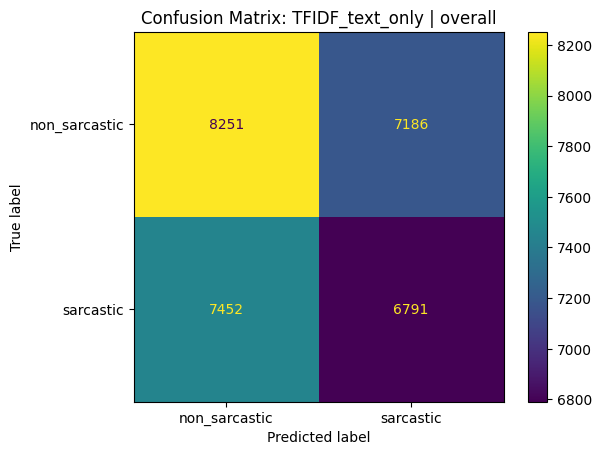


TFIDF_text_only | ISARCASM
        variant  dataset    n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc  tn  fp  fn  tp
TFIDF_text_only isarcasm 1400  0.574286              0.535             0.163265              0.48      0.243655  0.473716 0.574479 0.192099 708 492 104  96

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.8719    0.5900    0.7038      1200
    sarcastic     0.1633    0.4800    0.2437       200

     accuracy                         0.5743      1400
    macro avg     0.5176    0.5350    0.4737      1400
 weighted avg     0.7707    0.5743    0.6380      1400



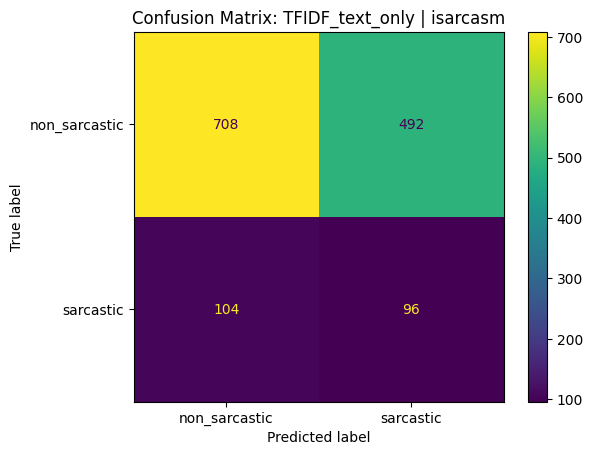


TFIDF_text_only | SARC
        variant dataset     n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc   tn   fp   fn   tp
TFIDF_text_only    sarc 27496  0.499818           0.499791             0.499198          0.476114      0.487383  0.499524 0.496652 0.496339 7205 6559 7194 6538

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.5004    0.5235    0.5117     13764
    sarcastic     0.4992    0.4761    0.4874     13732

     accuracy                         0.4998     27496
    macro avg     0.4998    0.4998    0.4995     27496
 weighted avg     0.4998    0.4998    0.4995     27496



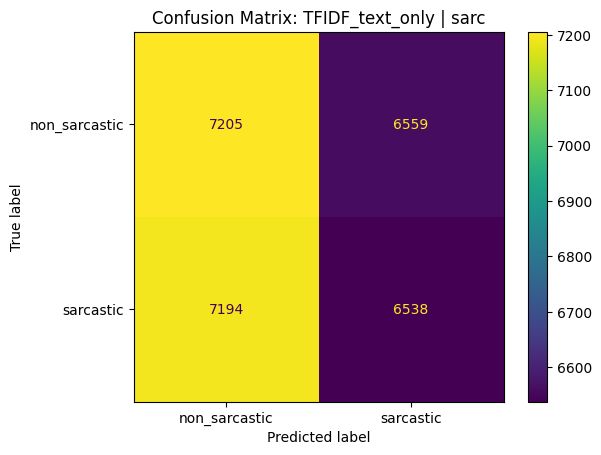


TFIDF_text_only | TWEETEVAL
        variant   dataset   n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc  tn  fp  fn  tp
TFIDF_text_only tweeteval 784  0.631378           0.609705             0.537671          0.504823       0.52073  0.610624 0.656601 0.592804 338 135 154 157

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.6870    0.7146    0.7005       473
    sarcastic     0.5377    0.5048    0.5207       311

     accuracy                         0.6314       784
    macro avg     0.6123    0.6097    0.6106       784
 weighted avg     0.6278    0.6314    0.6292       784



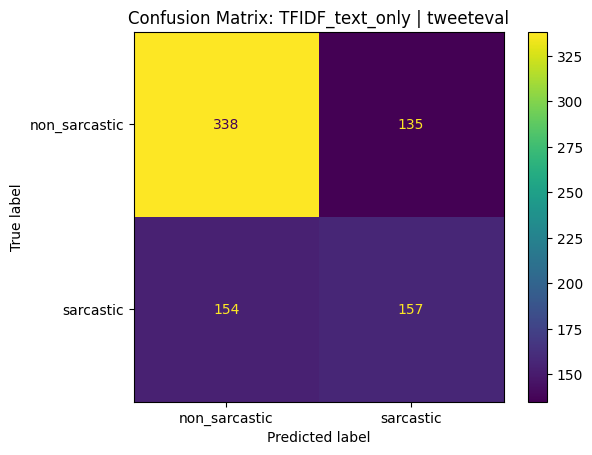

Saved text-only vectorizer and model to models/


In [20]:
tfidf_text = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_text.fit_transform(X_train_text)
X_test_tfidf = tfidf_text.transform(X_test_text)

lr_text = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42,
)

lr_text.fit(X_train_tfidf, y_train)

results_text_only = evaluate_by_dataset(
    model=lr_text,
    X_test=X_test_tfidf,
    test_df=test_df,
    y_test=y_test,
    variant_name="TFIDF_text_only",
)

joblib.dump(tfidf_text, "models/tfidf_text_vectorizer.joblib")
joblib.dump(lr_text, "models/lr_text_only.joblib")
print("Saved text-only vectorizer and model to models/")

Scale ESR numeric features, combine them with TF-IDF text vectors into a hybrid feature set, train and evaluate a LR model


TFIDF_plus_ESR | OVERALL
       variant dataset     n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc   tn   fp   fn   tp
TFIDF_plus_ESR overall 29680  0.509232           0.508026             0.488415          0.478059      0.483182  0.507982 0.510993 0.487244 8305 7132 7434 6809

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.5277    0.5380    0.5328     15437
    sarcastic     0.4884    0.4781    0.4832     14243

     accuracy                         0.5092     29680
    macro avg     0.5080    0.5080    0.5080     29680
 weighted avg     0.5088    0.5092    0.5090     29680



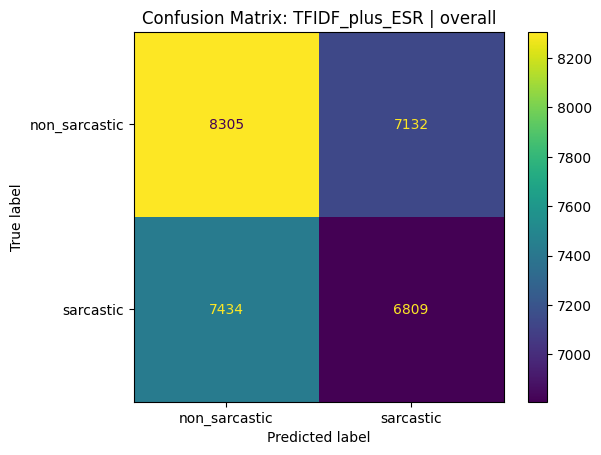


TFIDF_plus_ESR | ISARCASM
       variant  dataset    n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc  tn  fp  fn  tp
TFIDF_plus_ESR isarcasm 1400  0.627143            0.57625             0.192748             0.505      0.279006   0.51378 0.625125 0.220042 777 423  99 101

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.8870    0.6475    0.7486      1200
    sarcastic     0.1927    0.5050    0.2790       200

     accuracy                         0.6271      1400
    macro avg     0.5399    0.5762    0.5138      1400
 weighted avg     0.7878    0.6271    0.6815      1400



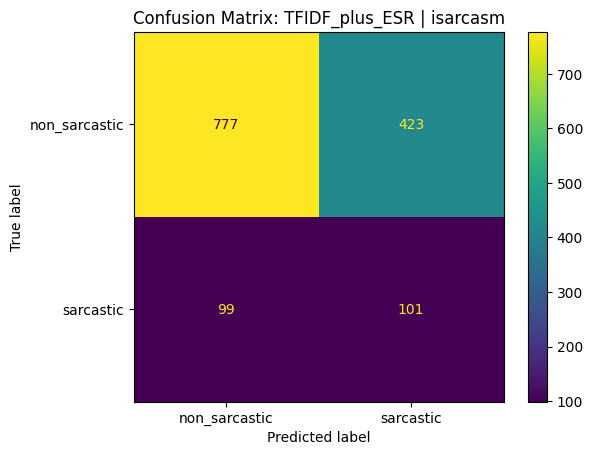


TFIDF_plus_ESR | SARC
       variant dataset     n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc   tn   fp   fn   tp
TFIDF_plus_ESR    sarc 27496  0.499454           0.499429              0.49882          0.477134      0.487736  0.499192 0.496548 0.496257 7181 6583 7180 6552

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.5000    0.5217    0.5106     13764
    sarcastic     0.4988    0.4771    0.4877     13732

     accuracy                         0.4995     27496
    macro avg     0.4994    0.4994    0.4992     27496
 weighted avg     0.4994    0.4995    0.4992     27496



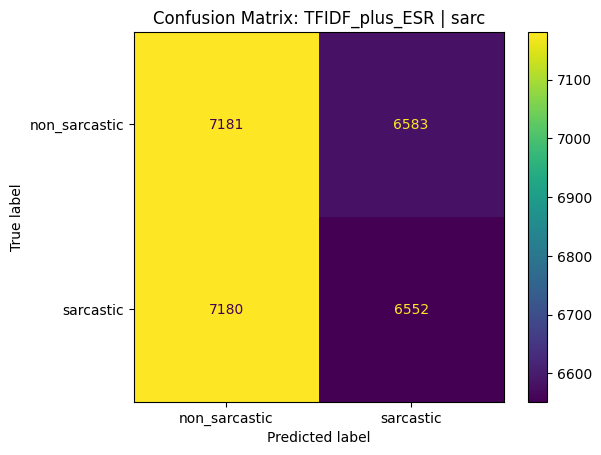


TFIDF_plus_ESR | TWEETEVAL
       variant   dataset   n  accuracy  balanced_accuracy  precision_sarcastic  recall_sarcastic  f1_sarcastic  macro_f1  roc_auc   pr_auc  tn  fp  fn  tp
TFIDF_plus_ESR tweeteval 784  0.641582           0.617611             0.553191          0.501608      0.526138  0.618967 0.667356 0.597197 347 126 155 156

Classification report:
               precision    recall  f1-score   support

non_sarcastic     0.6912    0.7336    0.7118       473
    sarcastic     0.5532    0.5016    0.5261       311

     accuracy                         0.6416       784
    macro avg     0.6222    0.6176    0.6190       784
 weighted avg     0.6365    0.6416    0.6381       784



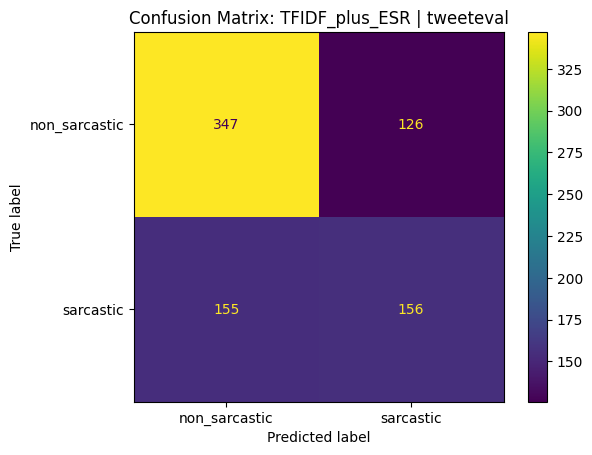

Saved ESR scaler and TF-IDF + ESR model to models/


In [21]:
# Scale ESR numeric features
scaler_esr = StandardScaler()

X_train_esr = scaler_esr.fit_transform(train_df[ESR_COLS])
X_test_esr = scaler_esr.transform(test_df[ESR_COLS])

# Convert dense ESR arrays to sparse so they can be concatenated with TF-IDF.
X_train_esr_sparse = csr_matrix(X_train_esr)
X_test_esr_sparse = csr_matrix(X_test_esr)

# Mode L = text TF-IDF + ESR features
X_train_mode_L = hstack([X_train_tfidf, X_train_esr_sparse])
X_test_mode_L = hstack([X_test_tfidf, X_test_esr_sparse])

lr_mode_L = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42,
)

lr_mode_L.fit(X_train_mode_L, y_train)

results_mode_L = evaluate_by_dataset(
    model=lr_mode_L,
    X_test=X_test_mode_L,
    test_df=test_df,
    y_test=y_test,
    variant_name="TFIDF_plus_ESR",
)

joblib.dump(scaler_esr, "models/esr_scaler.joblib")
joblib.dump(lr_mode_L, "models/lr_tfidf_plus_esr.joblib")
print("Saved ESR scaler and TF-IDF + ESR model to models/")


Combines both model result table

In [22]:
results_stage1 = pd.concat([results_text_only, results_mode_L], ignore_index=True)

ordered_cols = [
    "variant",
    "dataset",
    "n",
    "f1_sarcastic",
    "precision_sarcastic",
    "recall_sarcastic",
    "macro_f1",
    "pr_auc",
    "roc_auc",
    "balanced_accuracy",
    "accuracy",
    "tn",
    "fp",
    "fn",
    "tp",
]

results_stage1 = results_stage1[ordered_cols]

print("\nFinal Stage 1 results:")
print(results_stage1.to_string(index=False))

results_stage1.to_csv("results/stage1_tfidf_lr_results.csv", index=False)
print("\nSaved results to results/stage1_tfidf_lr_results.csv")


Final Stage 1 results:
        variant   dataset     n  f1_sarcastic  precision_sarcastic  recall_sarcastic  macro_f1   pr_auc  roc_auc  balanced_accuracy  accuracy   tn   fp   fn   tp
TFIDF_text_only   overall 29680      0.481290             0.485870          0.476796  0.505610 0.485032 0.506707           0.505645  0.506806 8251 7186 7452 6791
TFIDF_text_only  isarcasm  1400      0.243655             0.163265          0.480000  0.473716 0.192099 0.574479           0.535000  0.574286  708  492  104   96
TFIDF_text_only      sarc 27496      0.487383             0.499198          0.476114  0.499524 0.496339 0.496652           0.499791  0.499818 7205 6559 7194 6538
TFIDF_text_only tweeteval   784      0.520730             0.537671          0.504823  0.610624 0.592804 0.656601           0.609705  0.631378  338  135  154  157
 TFIDF_plus_ESR   overall 29680      0.483182             0.488415          0.478059  0.507982 0.487244 0.510993           0.508026  0.509232 8305 7132 7434 6809
 TFI

### 2.2 Training Existing Pre-Trained Models

We evaluate two strong pre-trained transformer models, BERTweet and RoBERTa, on TweetEval, iSarcasm, and SARC without task-specific fine-tuning to establish a benchmark

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (f1_score, classification_report, confusion_matrix, accuracy_score)
from tqdm.auto import tqdm
import warnings
import os

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 32
MAX_LEN = 128

os.makedirs("results", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

print(f"Device : {DEVICE}")
print(f"Batch : {BATCH}")
print(f"Max len: {MAX_LEN}")

# Minimal Dataset wrapper so DataLoader can batch plain strings.
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = [str(t) for t in texts]
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx]

# input normalisation for BERTweet
def format_for_bertweet(text):
    import re
    text = re.sub(r"http\S+|www\.\S+", "HTTPURL", str(text))
    text = re.sub(r"@\w+", "@USER", text)
    return re.sub(r"\s+", " ", text).strip()

# Batched inference over a list of tweets/comments.
def run_inference(model, tokenizer, texts, is_bertweet=False):
    processed = [format_for_bertweet(t) if is_bertweet else str(t) for t in texts]
    loader = DataLoader(TextDataset(processed), batch_size=BATCH, shuffle=False)
    all_preds, all_probs = [], []

    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc="  inference", leave=False):
            enc = tokenizer(
                batch, truncation=True, padding=True,
                max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1)
            preds  = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.max(dim=-1).values.cpu().numpy().tolist())

    return np.array(all_preds), np.array(all_probs)

"""
Render a labelled confusion matrix heatmap.
Rows = true labels, columns = predicted labels.
"""
def plot_confusion_matrix(cm, label_names, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"pred:{n}" for n in label_names],
        yticklabels=[f"true:{n}" for n in label_names],
        ax=ax
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved -> {save_path}")
    plt.show()
    plt.close()

# full classification report and confusion matrix,
def evaluate_model(model_name, dataset_name, model, tokenizer, texts, labels, is_bertweet=False):
    print(f"\n{'='*62}")
    print(f"  Model: {model_name}  |  Dataset: {dataset_name}")
    print(f"{'='*62}")
    print(f"  Samples: {len(texts):,}")

    y_pred, y_prob = run_inference(model, tokenizer, texts, is_bertweet)
    y_true = np.array(labels)

    # Enforce strict labels based on dataset type
    _SARCASM_DATASETS = {"iSarcasm", "SARC 2.0"}
    if dataset_name in _SARCASM_DATASETS:
        label_names = ["not sarcastic", "sarcastic"]
    else:
        label_names = ["not ironic", "ironic"]

    macro_f1  = f1_score(y_true, y_pred, average="macro")
    accuracy  = accuracy_score(y_true, y_pred)

    print(f"\n Macro-F1 : {macro_f1:.4f}  |  Accuracy : {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix (rows = true, cols = predicted):")
    cm_df = pd.DataFrame(
        cm,
        index  =[f"true:{n}" for n in label_names],
        columns=[f"pred:{n}" for n in label_names],
    )
    print(cm_df.to_string())

    # Save labelled confusion matrix figure for the report
    safe_name = f"{model_name}_{dataset_name}".replace(" ", "_").replace("/", "-")
    fig_path  = f"results/figures/cm_{safe_name}.png"
    plot_confusion_matrix(cm, label_names, title=f"{model_name} on {dataset_name}", save_path=fig_path)

    report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
    summary = {
        "model": model_name,
        "dataset": dataset_name,
        "n_samples": len(texts),
        "accuracy": round(accuracy, 4),
        "precision_macro": round(report["macro avg"]["precision"], 4),
        "recall_macro": round(report["macro avg"]["recall"], 4),
        "macro_f1": round(macro_f1, 4),
    }
    return summary, y_true, y_pred

# Loading both models upfront
print("Loading BERTweet (pysentimiento/bertweet-irony)")
tokenizer_bw = AutoTokenizer.from_pretrained("pysentimiento/bertweet-irony")
model_bw = (AutoModelForSequenceClassification
            .from_pretrained("pysentimiento/bertweet-irony")
            .to(DEVICE))
model_bw.eval()
print(f"  Label map: {model_bw.config.id2label}")

print("\nLoading RoBERTa (cardiffnlp/twitter-roberta-base-irony)")
tokenizer_rob = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-irony")
model_rob = (AutoModelForSequenceClassification
             .from_pretrained("cardiffnlp/twitter-roberta-base-irony")
             .to(DEVICE))
model_rob.eval()
print(f"  Label map: {model_rob.config.id2label}")

# Split TweetEval and SARC from the unified dataframe
try:
    test_te = test_df[test_df["dataset"] == "tweeteval"].copy()
    test_sarc = test_df[test_df["dataset"] == "sarc"].copy()
    print(f"TweetEval test loaded : {len(test_te):,} rows")
    print(f"SARC 2.0 test loaded  : {len(test_sarc):,} rows")
except NameError:
    print("Warning: test_df not found in memory. Please ensure previous sections were run.")

ISARCASM_TEST_URL = "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/test/task_A_En_test.csv"

def load_isarcasm(path_or_url):
    df = pd.read_csv(path_or_url)
    if "tweet" in df.columns:
        df = df.rename(columns={"tweet": "text"})
    if "sarcastic" in df.columns:
        df = df.rename(columns={"sarcastic": "label"})
    df = df.dropna(subset=["text", "label"])
    df["label"] = df["label"].astype(int)
    return df[["text", "label"]]

try:
    isarcasm_test = load_isarcasm(ISARCASM_TEST_URL)
    print(f"iSarcasm test loaded  : {len(isarcasm_test):,} rows")
except Exception as e:
    print(f"[WARNING] {e}")
    isarcasm_test = pd.DataFrame(columns=["text", "label"])

### 2.3 Evaluating Pre-Trained Models

This pipeline also handles tokenization and batched inference, reports key metrics such as accuracy and Macro-F1, generates confusion matrices for each model–dataset pair, and saves summary tables and visualizations so we can compare in-distribution and cross-dataset generalization before moving to Stage 3 fine-tuning.

Device : cuda
Batch : 32
Max len: 128
Loading BERTweet (pysentimiento/bertweet-irony)


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/bertweet-irony
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Label map: {0: 'not ironic', 1: 'ironic'}

Loading RoBERTa (cardiffnlp/twitter-roberta-base-irony)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-irony
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Label map: {0: 'non_irony', 1: 'irony'}
TweetEval test loaded : 784 rows
SARC 2.0 test loaded  : 27,496 rows
iSarcasm test loaded  : 1,400 rows

  Model: BERTweet  |  Dataset: TweetEval
  Samples: 784


  inference:   0%|          | 0/25 [00:00<?, ?it/s]


  Macro-F1 : 0.8193  |  Accuracy : 0.8202

Classification Report:
              precision    recall  f1-score   support

  not ironic       0.95      0.74      0.83       473
      ironic       0.70      0.95      0.81       311

    accuracy                           0.82       784
   macro avg       0.83      0.84      0.82       784
weighted avg       0.85      0.82      0.82       784

Confusion Matrix (rows = true, cols = predicted):
                 pred:not ironic  pred:ironic
true:not ironic              349          124
true:ironic                   17          294
  Figure saved -> results/figures/cm_BERTweet_TweetEval.png


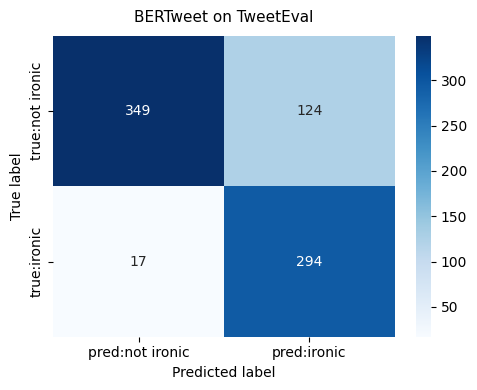


  Model: RoBERTa  |  Dataset: TweetEval
  Samples: 784


  inference:   0%|          | 0/25 [00:00<?, ?it/s]


  Macro-F1 : 0.7106  |  Accuracy : 0.7347

Classification Report:
              precision    recall  f1-score   support

  not ironic       0.75      0.85      0.79       473
      ironic       0.71      0.56      0.63       311

    accuracy                           0.73       784
   macro avg       0.73      0.71      0.71       784
weighted avg       0.73      0.73      0.73       784

Confusion Matrix (rows = true, cols = predicted):
                 pred:not ironic  pred:ironic
true:not ironic              401           72
true:ironic                  136          175
  Figure saved -> results/figures/cm_RoBERTa_TweetEval.png


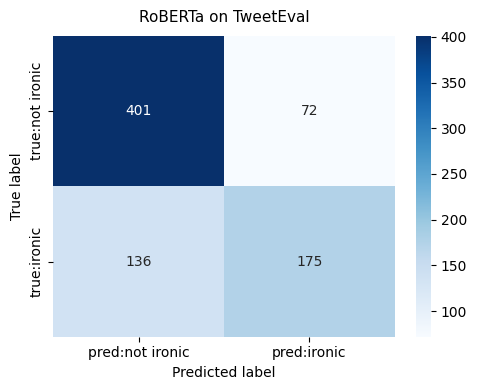


  Model: BERTweet  |  Dataset: iSarcasm
  Samples: 1,400


  inference:   0%|          | 0/44 [00:00<?, ?it/s]


  Macro-F1 : 0.6131  |  Accuracy : 0.6986

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.95      0.68      0.79      1200
    sarcastic       0.30      0.80      0.43       200

     accuracy                           0.70      1400
    macro avg       0.62      0.74      0.61      1400
 weighted avg       0.86      0.70      0.74      1400

Confusion Matrix (rows = true, cols = predicted):
                    pred:not sarcastic  pred:sarcastic
true:not sarcastic                 818             382
true:sarcastic                      40             160
  Figure saved -> results/figures/cm_BERTweet_iSarcasm.png


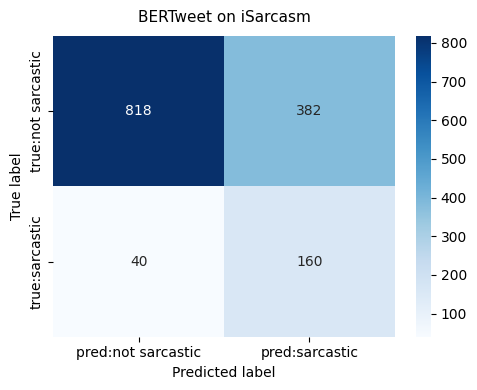


  Model: RoBERTa  |  Dataset: iSarcasm
  Samples: 1,400


  inference:   0%|          | 0/44 [00:00<?, ?it/s]


  Macro-F1 : 0.6562  |  Accuracy : 0.7479

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.96      0.74      0.83      1200
    sarcastic       0.34      0.81      0.48       200

     accuracy                           0.75      1400
    macro avg       0.65      0.77      0.66      1400
 weighted avg       0.87      0.75      0.78      1400

Confusion Matrix (rows = true, cols = predicted):
                    pred:not sarcastic  pred:sarcastic
true:not sarcastic                 885             315
true:sarcastic                      38             162
  Figure saved -> results/figures/cm_RoBERTa_iSarcasm.png


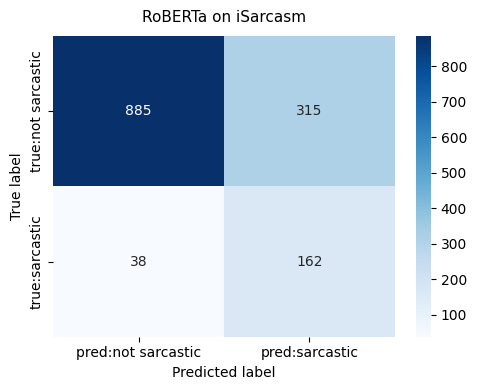


  Model: BERTweet  |  Dataset: SARC 2.0
  Samples: 27,496


  inference:   0%|          | 0/860 [00:00<?, ?it/s]


  Macro-F1 : 0.4967  |  Accuracy : 0.5014

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.50      0.60      0.55     13764
    sarcastic       0.50      0.41      0.45     13732

     accuracy                           0.50     27496
    macro avg       0.50      0.50      0.50     27496
 weighted avg       0.50      0.50      0.50     27496

Confusion Matrix (rows = true, cols = predicted):
                    pred:not sarcastic  pred:sarcastic
true:not sarcastic                8216            5548
true:sarcastic                    8162            5570
  Figure saved -> results/figures/cm_BERTweet_SARC_2.0.png


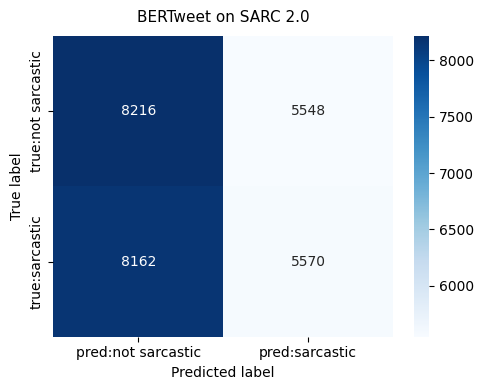


  Model: RoBERTa  |  Dataset: SARC 2.0
  Samples: 27,496


  inference:   0%|          | 0/860 [00:00<?, ?it/s]


  Macro-F1 : 0.5019  |  Accuracy : 0.5028

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.50      0.54      0.52     13764
    sarcastic       0.50      0.46      0.48     13732

     accuracy                           0.50     27496
    macro avg       0.50      0.50      0.50     27496
 weighted avg       0.50      0.50      0.50     27496

Confusion Matrix (rows = true, cols = predicted):
                    pred:not sarcastic  pred:sarcastic
true:not sarcastic                7483            6281
true:sarcastic                    7391            6341
  Figure saved -> results/figures/cm_RoBERTa_SARC_2.0.png


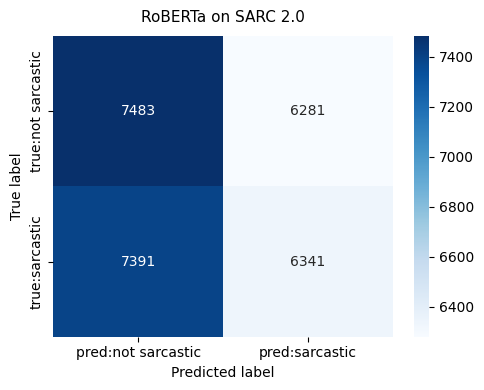

 STAGE 2 – PRE-TRAINED INFERENCE  |  RESULTS SUMMARY
   model   dataset  n_samples  accuracy  precision_macro  recall_macro  macro_f1
BERTweet TweetEval        784    0.8202           0.8285        0.8416    0.8193
 RoBERTa TweetEval        784    0.7347           0.7276        0.7052    0.7106
BERTweet  iSarcasm       1400    0.6986           0.6243        0.7408    0.6131
 RoBERTa  iSarcasm       1400    0.7479           0.6492        0.7738    0.6562
BERTweet  SARC 2.0      27496    0.5014           0.5013        0.5013    0.4967
 RoBERTa  SARC 2.0      27496    0.5028           0.5027        0.5027    0.5019

Saved -> results/stage2_pretrained_summary.csv
Figure saved -> results/figures/overview_all_models.png


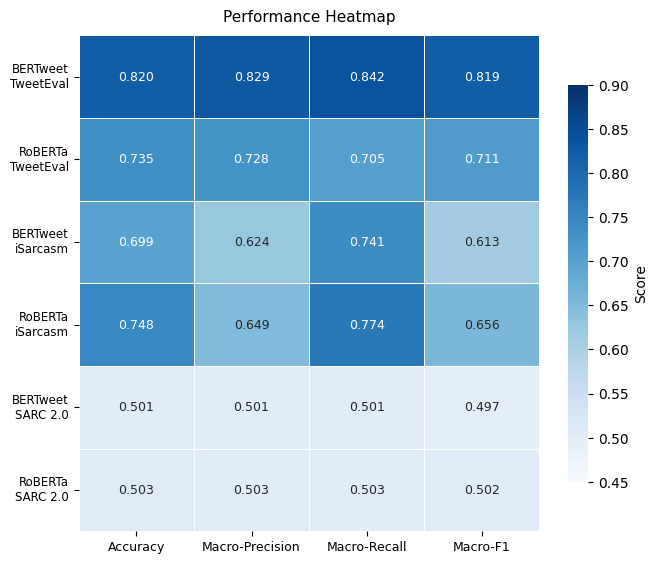

  Per-class Recall & Precision  |  TweetEval (Irony Detection)
   Model   Dataset  Accuracy  Recall (not ironic)  Recall (ironic)  Precision (not ironic)  Precision (ironic)
BERTweet TweetEval    0.8202               0.7378           0.9453                  0.9536              0.7033
 RoBERTa TweetEval    0.7347               0.8478           0.5627                  0.7467              0.7085
  Per-class Recall & Precision  |  iSarcasm & SARC 2.0 (Sarcasm Detection)
   Model  Dataset  Accuracy  Recall (not sarcastic)  Recall (sarcastic)  Precision (not sarcastic)  Precision (sarcastic)
BERTweet iSarcasm    0.6986                  0.6817              0.8000                     0.9534                 0.2952
 RoBERTa iSarcasm    0.7479                  0.7375              0.8100                     0.9588                 0.3396
BERTweet SARC 2.0    0.5014                  0.5969              0.4056                     0.5016                 0.5010
 RoBERTa SARC 2.0    0.5028              

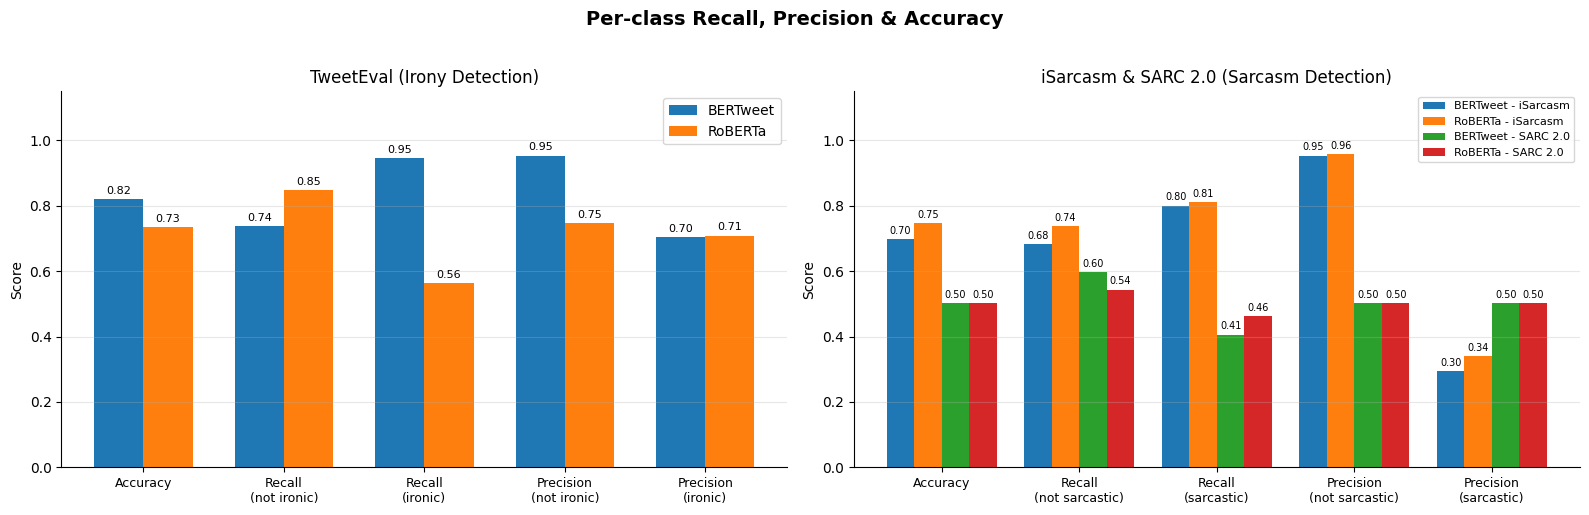

In [ ]:
all_results = []
all_preds   = {}

# TweetEval
if 'test_te' in locals() and not test_te.empty:
    te_texts  = test_te["text"].tolist()
    te_labels = test_te["label"].tolist()

    _res, _yt, _yp = evaluate_model("BERTweet", "TweetEval", model_bw, tokenizer_bw, te_texts, te_labels, is_bertweet=True)
    all_results.append(_res)
    all_preds[("BERTweet", "TweetEval")] = (_yt, _yp)

    _res, _yt, _yp = evaluate_model("RoBERTa", "TweetEval", model_rob, tokenizer_rob, te_texts, te_labels, is_bertweet=False)
    all_results.append(_res)
    all_preds[("RoBERTa", "TweetEval")] = (_yt, _yp)

# iSarcasm
if 'isarcasm_test' in locals() and not isarcasm_test.empty:
    isa_texts  = isarcasm_test["text"].tolist()
    isa_labels = isarcasm_test["label"].tolist()

    _res, _yt, _yp = evaluate_model("BERTweet", "iSarcasm", model_bw, tokenizer_bw, isa_texts, isa_labels, is_bertweet=True)
    all_results.append(_res)
    all_preds[("BERTweet", "iSarcasm")] = (_yt, _yp)

    _res, _yt, _yp = evaluate_model("RoBERTa", "iSarcasm", model_rob, tokenizer_rob, isa_texts, isa_labels, is_bertweet=False)
    all_results.append(_res)
    all_preds[("RoBERTa", "iSarcasm")] = (_yt, _yp)

# SARC 2.0
if 'test_sarc' in locals() and not test_sarc.empty:
    sarc_texts = test_sarc["text"].tolist()
    sarc_labels = test_sarc["label"].tolist()

    _res, _yt, _yp = evaluate_model("BERTweet", "SARC 2.0", model_bw, tokenizer_bw, sarc_texts, sarc_labels, is_bertweet=True)
    all_results.append(_res)
    all_preds[("BERTweet", "SARC 2.0")] = (_yt, _yp)

    _res, _yt, _yp = evaluate_model("RoBERTa", "SARC 2.0", model_rob, tokenizer_rob, sarc_texts, sarc_labels, is_bertweet=False)
    all_results.append(_res)
    all_preds[("RoBERTa", "SARC 2.0")] = (_yt, _yp)

summary = pd.DataFrame(all_results)

print(" STAGE 2 – PRE-TRAINED INFERENCE  |  RESULTS SUMMARY")
print(summary.to_string(index=False))
print()

# Persist so Stage 4 (Quantitative Evaluation) can load it
summary.to_csv("results/stage2_pretrained_summary.csv", index=False)
print("Saved -> results/stage2_pretrained_summary.csv")

df_heat = pd.DataFrame(all_results)

# Rename columns to match the heatmap formatting
df_heat = df_heat.rename(columns={
    "model": "Model",
    "dataset": "Dataset",
    "accuracy": "Accuracy",
    "precision_macro": "Macro-Precision",
    "recall_macro": "Macro-Recall",
    "macro_f1": "Macro-F1"
})

df_heat["Model / Dataset"] = df_heat["Model"] + "\n" + df_heat["Dataset"]
metrics = ["Accuracy", "Macro-Precision", "Macro-Recall", "Macro-F1"]
heat_data = df_heat.set_index("Model / Dataset")[metrics]

fig, ax_heat = plt.subplots(figsize=(7, 6))

sns.heatmap(
    heat_data,
    ax=ax_heat,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.45,
    vmax=0.90,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Score"},
    annot_kws={"size": 9},
)
ax_heat.set_title("Performance Heatmap", fontsize=11, pad=10)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")
ax_heat.tick_params(axis="x", labelsize=9)
ax_heat.tick_params(axis="y", labelsize=8.5, rotation=0)

plt.tight_layout(pad=2.0)
save_path = "results/figures/overview_all_models.png"
plt.savefig(save_path, dpi=180, bbox_inches="tight")
print(f"Figure saved -> {save_path}")
plt.show()
plt.close()

rows_irony = []
rows_sarcasm = []

_SARCASM_DATASETS = {"iSarcasm", "SARC 2.0"}

for (model_name, dataset_name), (y_true, y_pred) in all_preds.items():
    report = classification_report(y_true, y_pred, output_dict=True)
    acc = accuracy_score(y_true, y_pred)

    if dataset_name in _SARCASM_DATASETS:
        # Sarcasm detection (iSarcasm, SARC 2.0): class 0 = not sarcastic, class 1 = sarcastic
        row = {
            "Model": model_name,
            "Dataset": dataset_name,
            "Accuracy": round(acc, 4),
            "Recall (not sarcastic)": round(report["0"]["recall"], 4),
            "Recall (sarcastic)": round(report["1"]["recall"], 4),
            "Precision (not sarcastic)": round(report["0"]["precision"], 4),
            "Precision (sarcastic)": round(report["1"]["precision"], 4),
        }
        rows_sarcasm.append(row)
    else:
        # Irony detection (TweetEval): class 0 = not ironic, class 1 = ironic
        row = {
            "Model": model_name,
            "Dataset": dataset_name,
            "Accuracy": round(acc, 4),
            "Recall (not ironic)": round(report["0"]["recall"], 4),
            "Recall (ironic)": round(report["1"]["recall"], 4),
            "Precision (not ironic)": round(report["0"]["precision"], 4),
            "Precision (ironic)": round(report["1"]["precision"], 4),
        }
        rows_irony.append(row)

df_irony = pd.DataFrame(rows_irony)
df_sarcasm = pd.DataFrame(rows_sarcasm)

# Table 1: TweetEval (Irony Detection)
print("  Per-class Recall & Precision  |  TweetEval (Irony Detection)")
if not df_irony.empty:
    print(df_irony.to_string(index=False))

# Table 2: iSarcasm + SARC 2.0 (Sarcasm Detection)
print("  Per-class Recall & Precision  |  iSarcasm & SARC 2.0 (Sarcasm Detection)")
if not df_sarcasm.empty:
    print(df_sarcasm.to_string(index=False))
metrics_irony = ["Accuracy", "Recall\n(not ironic)",     "Recall\n(ironic)",
                   "Precision\n(not ironic)",  "Precision\n(ironic)"]
metric_keys_irony = ["Accuracy", "Recall (not ironic)", "Recall (ironic)",
                     "Precision (not ironic)", "Precision (ironic)"]

metrics_sarc = ["Accuracy", "Recall\n(not sarcastic)", "Recall\n(sarcastic)",
                   "Precision\n(not sarcastic)", "Precision\n(sarcastic)"]
metric_keys_sarc = ["Accuracy", "Recall (not sarcastic)", "Recall (sarcastic)",
                    "Precision (not sarcastic)", "Precision (sarcastic)"]

x = np.arange(len(metrics_irony))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-class Recall, Precision & Accuracy", fontsize=14, fontweight="bold", y=1.02)

# Plot 1: TweetEval (Irony Detection, in-distribution)
ax1 = axes[0]
if not df_irony.empty:
    for i, row in df_irony.iterrows():
        vals = [row[k] for k in metric_keys_irony]
        offset = (i - len(df_irony) / 2 + 0.5) * width
        bars = ax1.bar(x + offset, vals, width, label=row["Model"])
        for bar, val in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax1.set_title("TweetEval (Irony Detection)", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_irony, fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)

# Plot 2: iSarcasm & SARC 2.0 (Sarcasm Detection, out-of-distribution)
ax2 = axes[1]
if not df_sarcasm.empty:
    n = len(df_sarcasm)
    w = 0.2
    for i, row in df_sarcasm.reset_index(drop=True).iterrows():
        vals = [row[k] for k in metric_keys_sarc]
        offset = (i - n / 2 + 0.5) * w
        bars = ax2.bar(x + offset, vals, w, label=f"{row['Model']} - {row['Dataset']}")
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax2.set_title("iSarcasm & SARC 2.0 (Sarcasm Detection)", fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_sarc, fontsize=9)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Score")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_path = "results/figures/model_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Figure saved -> {save_path}")
plt.show()

## Stage 3 Fine Tuning our own model

In this stage, we fine-tune our own RoBERTa-based sarcasm classifier on TweetEval using three emoji-handling modes (remove, keep, and demojize), with validation-driven early stopping to select the best checkpoint. We then test how well each fine-tuned variant generalizes to both in-domain data (TweetEval) and unseen data (iSarcasm), and save the resulting metrics so they can be compared against the Stage 1 baselines and Stage 2 pre-trained-only models

### 3.1 Setup & Config

Define the RoBERTa model, hyperparameters, emoji modes, paths, and GPU/device settings.

In [24]:
# Stage 3 Part 1 — Setup & Config
import os
import json
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# GPU check
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Model
MODEL_ID = 'cardiffnlp/twitter-roberta-base'

# Hyperparameters
MAX_LEN = 128
BATCH_SIZE = 32
MAX_EPOCHS = 5
LR = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
PATIENCE = 2 # early stopping on val Macro-F1
SEED = 42

# Experiment dimensions
EMOJI_MODES = ['T', 'K', 'D']
TRAIN_CONFIGS = ['tweeteval_only']
# TRAIN_CONFIGS = ['tweeteval_only', 'combined']
MODE_COL = {
    'T': 'text_mode_T',
    'K': 'text_mode_K',
    'D': 'text_mode_D',
}

# Paths
DATA_DIR = 'data'
MODELS_DIR = 'models/stage3'
RESULTS_DIR = 'results'

for path in [MODELS_DIR, RESULTS_DIR]:
    os.makedirs(path, exist_ok=True)

print(f"\nModel : {MODEL_ID}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Max epochs : {MAX_EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Max length : {MAX_LEN}")
print(f"Patience : {PATIENCE}")
print(f"Emoji modes : {EMOJI_MODES}")
print(f"Train configs: {TRAIN_CONFIGS}")
print(f"\nFolders ready: {MODELS_DIR}, {RESULTS_DIR}")

Device: cuda
GPU: Tesla T4

Model : cardiffnlp/twitter-roberta-base
Batch size : 32
Max epochs : 5
Learning rate: 1e-05
Max length : 128
Patience : 2
Emoji modes : ['T', 'K', 'D']
Train configs: ['tweeteval_only']

Folders ready: models/stage3, results


### 3.2 Load and Prepare Datasets

Load enriched train/validation/test data, create TweetEval splits, checks required columns, and verify label distributions

In [ ]:
# Set seed
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load enriched CSVs
train_df = pd.read_csv(f"{DATA_DIR}/train_enriched.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val_enriched.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test_enriched.csv")

print(f"Train : {len(train_df)} rows")
print(f"Val : {len(val_df)} rows")
print(f"Test : {len(test_df)} rows")

# Separate TweetEval test set
test_tweeteval = test_df[test_df["dataset"] == "tweeteval"].reset_index(drop=True)

print(f"\nTweetEval test : {len(test_tweeteval)} rows")

# Separate train configs
train_tweeteval_only = train_df[train_df["dataset"] == "tweeteval"].reset_index(drop=True)
train_combined = train_df.reset_index(drop=True)

print(f"\nTrain tweeteval_only : {len(train_tweeteval_only)} rows")
print(f"Train combined : {len(train_combined)} rows")

# Verification text mode columns exist
required_cols = ["text_mode_T", "text_mode_K", "text_mode_D", "label"]
for col in required_cols:
    assert col in train_df.columns, f"Missing column: {col}"
print(f"\nAll required columns present: {required_cols}")

# Distribution check
print("\nVal label distribution:")
print(val_df["label"].value_counts().to_string())
print("\nTweetEval test label distribution:")
print(test_tweeteval["label"].value_counts().to_string())

Train : 115511 rows
Val : 955 rows
Test : 29680 rows

TweetEval test : 784 rows
SARC test : 27496 rows

Train tweeteval_only : 2862 rows
Train combined : 115511 rows

All required columns present: ['text_mode_T', 'text_mode_K', 'text_mode_D', 'label']

Val label distribution:
label
0    499
1    456

TweetEval test label distribution:
label
0    473
1    311

SARC test label distribution:
label
0    13764
1    13732


### 3.3 Tokenizer and Dataset Class

Initialize the tokenizer and build a custom PyTorch dataset class to convert text and labels into model-ready tensors

In [26]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

# Loading tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"Tokenizer loaded: {MODEL_ID}")
print(f"Vocab size: {tokenizer.vocab_size}")

# Dataset class
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = [str(t) for t in texts]
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length = self.max_len,
            padding  = "max_length",
            truncation = True,
            return_tensors = "pt",
        )
        return {
            "input_ids" : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "label" : torch.tensor(self.labels[idx], dtype=torch.long),
        }

# Test
sample_texts = train_tweeteval_only["text_mode_K"].tolist()[:4]
sample_labels = train_tweeteval_only["label"].tolist()[:4]

sample_ds = SarcasmDataset(sample_texts, sample_labels, tokenizer, MAX_LEN)
sample_loader = DataLoader(sample_ds, batch_size=2)
batch = next(iter(sample_loader))

print(f"\nSample batch:")
print(f" input_ids shape : {batch['input_ids'].shape}")
print(f" attention_mask shape: {batch['attention_mask'].shape}")
print(f" labels : {batch['label']}")
print("\nDataset class working correctly")

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded: cardiffnlp/twitter-roberta-base
Vocab size: 50265

Sample batch:
 input_ids shape : torch.Size([2, 128])
 attention_mask shape: torch.Size([2, 128])
 labels : tensor([1, 0])

Dataset class working correctly


### 3.4 Model Loading and Training Utilities

Define reusable functions for loading the model, running evaluation, and training one epoch with optimization, scheduling, and gradient clipping.

In [27]:
# Stage 3 | Part 4 — Model Loading and Training Utilities
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

def load_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels = 2,
        use_safetensors = True,
    )
    model = model.to(DEVICE)
    return model

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(
                input_ids = input_ids,
                attention_mask = attention_mask,
                labels = labels,
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    avg_loss = total_loss / len(loader)
    return macro_f1, avg_loss, all_labels, all_preds

def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        # with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
        outputs = model(
            input_ids = input_ids,
            attention_mask = attention_mask,
            labels = labels,
        )
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)

# Tests
print("Loading model")
test_model = load_model()
total_params = sum(p.numel() for p in test_model.parameters())
print(f"Model loaded on: {next(test_model.parameters()).device}")
print(f"Total parameters: {total_params:,}")

del test_model
torch.cuda.empty_cache()
print("Model check passed — GPU memory freed")

Loading model


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda:0
Total parameters: 124,647,170
Model check passed — GPU memory freed


### 3.5 Main Training Loop (TweetEval)

Train separate models for each emoji mode with early stopping, save the best checkpoints, and reports TweetEval test performance

In [28]:
import copy
from tqdm.auto import tqdm

all_results = []
all_histories = {}

for emoji_mode in EMOJI_MODES:
    run_name = f"roberta_tweeteval_{emoji_mode}"
    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"{'='*60}")

    text_col = MODE_COL[emoji_mode]
    train_source = train_tweeteval_only.dropna(subset=[text_col, "label"]).copy()
    val_source = val_df[val_df["dataset"] == "tweeteval"].reset_index(drop=True)

    train_texts = train_source[text_col].tolist()
    train_labels = train_source["label"].tolist()
    val_texts = val_source[text_col].tolist()
    val_labels = val_source["label"].tolist()

    print(f" Train: {len(train_texts)} | Val: {len(val_texts)}")

    train_ds = SarcasmDataset(train_texts, train_labels, tokenizer, MAX_LEN)
    val_ds = SarcasmDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = load_model()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-8)

    total_steps  = len(train_loader) * MAX_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps = warmup_steps, num_training_steps = total_steps,
    )

    best_val_f1 = -1.0
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_f1, val_loss, _, _ = evaluate(model, val_loader)

        history.append({
            "epoch" : epoch,
            "train_loss": round(train_loss, 4),
            "val_loss" : round(val_loss,   4),
            "val_f1" : round(val_f1,     4),
        })

        print(f" Epoch {epoch}/{MAX_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_f1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f" New best val_f1: {best_val_f1:.4f} — checkpoint saved")
        else:
            patience_counter += 1
            print(f" No improvement. Patience: {patience_counter}/{PATIENCE}")
            if patience_counter >= PATIENCE:
                print(f" Early stopping triggered.")
                break

    all_histories[run_name] = history

    # Save checkpoint
    ckpt_dir = f"{MODELS_DIR}/{run_name}"
    os.makedirs(ckpt_dir, exist_ok=True)
    model.load_state_dict(best_model_state)
    model.save_pretrained(ckpt_dir)
    tokenizer.save_pretrained(ckpt_dir)
    print(f" Saved: {ckpt_dir}")

    # Evaluate on TweetEval test
    te_texts = test_tweeteval[text_col].tolist()
    te_labels = test_tweeteval["label"].tolist()
    te_ds = SarcasmDataset(te_texts, te_labels, tokenizer, MAX_LEN)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    te_f1, _, te_labels_out, te_preds = evaluate(model, te_loader)
    print(f" TweetEval Test Macro-F1: {te_f1:.4f}")
    print(classification_report(te_labels_out, te_preds,
                                  target_names=["not_irony", "irony"]))

    all_results.append({
        "run_name" : run_name,
        "emoji_mode" : emoji_mode,
        "TweetEval_F1" : round(te_f1, 4),
    })

    pd.DataFrame(all_results).to_csv(f"{RESULTS_DIR}/stage3_tweeteval_results.csv", index=False)
    print(f" Results saved → {RESULTS_DIR}/stage3_tweeteval_results.csv")

    del model
    torch.cuda.empty_cache()

print("\nAll TweetEval training runs complete.")
print(pd.DataFrame(all_results).to_string(index=False))


Run: roberta_tweeteval_T
 Train: 2862 | Val: 955


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Epoch 1/5 | train_loss: 0.6815 | val_loss: 0.6635 | val_f1: 0.5971
 New best val_f1: 0.5971 — checkpoint saved
 Epoch 2/5 | train_loss: 0.6168 | val_loss: 0.6197 | val_f1: 0.6366
 New best val_f1: 0.6366 — checkpoint saved
 Epoch 3/5 | train_loss: 0.5189 | val_loss: 0.6071 | val_f1: 0.6709
 New best val_f1: 0.6709 — checkpoint saved
 Epoch 4/5 | train_loss: 0.4555 | val_loss: 0.6128 | val_f1: 0.6861
 New best val_f1: 0.6861 — checkpoint saved
 Epoch 5/5 | train_loss: 0.4142 | val_loss: 0.6167 | val_f1: 0.6936
 New best val_f1: 0.6936 — checkpoint saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Epoch 1/5 | train_loss: 0.6855 | val_loss: 0.6520 | val_f1: 0.5863
 New best val_f1: 0.5863 — checkpoint saved
 Epoch 2/5 | train_loss: 0.5781 | val_loss: 0.5652 | val_f1: 0.7037
 New best val_f1: 0.7037 — checkpoint saved
 Epoch 3/5 | train_loss: 0.4734 | val_loss: 0.5764 | val_f1: 0.7142
 New best val_f1: 0.7142 — checkpoint saved
 Epoch 4/5 | train_loss: 0.4129 | val_loss: 0.5862 | val_f1: 0.7141
 No improvement. Patience: 1/2
 Epoch 5/5 | train_loss: 0.3659 | val_loss: 0.5937 | val_f1: 0.7141
 No improvement. Patience: 2/2
 Early stopping triggered.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Saved: models/stage3/roberta_tweeteval_D
 TweetEval Test Macro-F1: 0.7238
              precision    recall  f1-score   support

   not_irony       0.79      0.75      0.77       473
       irony       0.65      0.70      0.68       311

    accuracy                           0.73       784
   macro avg       0.72      0.73      0.72       784
weighted avg       0.74      0.73      0.73       784

 Results saved → results/stage3_tweeteval_results.csv

All TweetEval training runs complete.
           run_name emoji_mode  TweetEval_F1
roberta_tweeteval_T          T        0.7194
roberta_tweeteval_K          K        0.7524
roberta_tweeteval_D          D        0.7238


### 3.6 iSarcasm Evaluation

Evaluate each fine-tuned checkpoint on unseen iSarcasm data, tunes the decision threshold for best Macro-F1.

In [29]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report

# Load iSarcasmEval
isarcasm_test = pd.read_csv(
    "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/test/task_A_En_test.csv"
)
isarcasm_texts = isarcasm_test["text"].tolist()
isarcasm_labels = isarcasm_test["sarcastic"].tolist()

print(f"iSarcasmEval: {len(isarcasm_test)} rows")
print(f"Label distribution:\n{isarcasm_test['sarcastic'].value_counts().to_string()}")

CHECKPOINTS = {
    "roberta_tweeteval_T": f"{MODELS_DIR}/roberta_tweeteval_T",
    "roberta_tweeteval_K": f"{MODELS_DIR}/roberta_tweeteval_K",
    "roberta_tweeteval_D": f"{MODELS_DIR}/roberta_tweeteval_D",
}

isarcasm_results = []

MODE_FN = {"T": apply_mode_T, "K": apply_mode_K, "D": apply_mode_D}

for run_name, ckpt_path in CHECKPOINTS.items():
    print(f"\nEvaluating: {run_name}")

    emoji_mode = run_name.split("_")[-1]
    mode_fn = MODE_FN[emoji_mode]

    ck_tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
    ck_model = AutoModelForSequenceClassification.from_pretrained(ckpt_path)
    ck_model = ck_model.to(DEVICE)
    ck_model.eval()

    texts = [mode_fn(normalize_text(t)) for t in isarcasm_texts]
    test_ds = SarcasmDataset(texts, isarcasm_labels, ck_tokenizer, MAX_LEN)
    loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Find optimal threshold
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            outputs = ck_model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_probs = np.array(all_probs)
    best_f1, best_thresh = 0, 0.5
    for thresh in np.arange(0.1, 0.95, 0.05):
        preds = (all_probs > thresh).astype(int)
        macro_f1 = f1_score(isarcasm_labels, preds, average="macro")
        if macro_f1 > best_f1:
            best_f1, best_thresh = macro_f1, thresh

    final_preds = (all_probs > best_thresh).astype(int)
    print(f"  iSarcasm Macro-F1: {best_f1:.4f} (threshold={best_thresh:.2f})")
    print(classification_report(isarcasm_labels, final_preds,
                                  target_names=["not_sarcastic", "sarcastic"]))

    isarcasm_results.append({
        "run_name" : run_name,
        "emoji_mode" : emoji_mode,
        "iSarcasm_F1" : round(best_f1, 4),
        "iSarcasm_threshold" : round(best_thresh, 2),
    })

    del ck_model
    torch.cuda.empty_cache()

# Save and print summary
isarcasm_df = pd.DataFrame(isarcasm_results)
isarcasm_df.to_csv(f"{RESULTS_DIR}/stage3_isarcasm_results.csv", index=False)

print("\n"+"="*60)
print("iSarcasmEval Results Summary")
print(isarcasm_df.to_string(index=False))
print(f"\nSaved → {RESULTS_DIR}/stage3_isarcasm_results.csv")

iSarcasmEval: 1400 rows
Label distribution:
sarcastic
0    1200
1     200

Evaluating: roberta_tweeteval_T


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  iSarcasm Macro-F1: 0.7108 (threshold=0.90)
               precision    recall  f1-score   support

not_sarcastic       0.91      0.94      0.93      1200
    sarcastic       0.56      0.45      0.50       200

     accuracy                           0.87      1400
    macro avg       0.74      0.69      0.71      1400
 weighted avg       0.86      0.87      0.86      1400


Evaluating: roberta_tweeteval_K


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  iSarcasm Macro-F1: 0.7232 (threshold=0.90)
               precision    recall  f1-score   support

not_sarcastic       0.91      0.95      0.93      1200
    sarcastic       0.59      0.46      0.52       200

     accuracy                           0.88      1400
    macro avg       0.75      0.70      0.72      1400
 weighted avg       0.87      0.88      0.87      1400


Evaluating: roberta_tweeteval_D


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  iSarcasm Macro-F1: 0.7215 (threshold=0.90)
               precision    recall  f1-score   support

not_sarcastic       0.91      0.95      0.93      1200
    sarcastic       0.60      0.45      0.51       200

     accuracy                           0.88      1400
    macro avg       0.75      0.70      0.72      1400
 weighted avg       0.87      0.88      0.87      1400


iSarcasmEval Results Summary
           run_name emoji_mode  iSarcasm_F1  iSarcasm_threshold
roberta_tweeteval_T          T       0.7108                 0.9
roberta_tweeteval_K          K       0.7232                 0.9
roberta_tweeteval_D          D       0.7215                 0.9

Saved → results/stage3_isarcasm_results.csv


## Stage 4 Qualitative Error Analysis

Here we look beyond aggregate scores and inspect where the model gets things wrong, using misclassified examples, confusion matrices and a final comparison table to understand error patterns and how the TweetEval fine-tuned model stacks up against the earlier baseline and pre-trained systems.

### 4.1 10 Missclassified Examples

Extract and inspect 10 misclassified TweetEval examples to see what kinds of texts the model struggles with, especially around emoji use and sarcasm cues

In [ ]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import emosent.emosent as _emo

# Load best model (mode K)
BEST_CKPT = "models/stage3/roberta_tweeteval_K"

ck_tokenizer = AutoTokenizer.from_pretrained(BEST_CKPT)
ck_model = AutoModelForSequenceClassification.from_pretrained(BEST_CKPT)
ck_model = ck_model.to(DEVICE)
ck_model.eval()

# Load TweetEval test set
test_texts = test_tweeteval["text_mode_K"].tolist()
test_labels = test_tweeteval["label"].tolist()
test_raw = test_tweeteval["text"].tolist()

test_ds = SarcasmDataset(test_texts, test_labels, ck_tokenizer, MAX_LEN)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

# Get predictions and probabilities
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"]

        outputs = ck_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)

        all_probs.extend(probs.cpu().numpy())
        probs = torch.softmax(outputs.logits, dim=1)
        preds = (probs[:, 1] > 0.7).long()  # custom threshold
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Find misclassified examples
misclassified_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(all_labels)}")

# Extract emoji features for each misclassified sample
esr_dict = {char: data["sentiment_score"]
            for char, data in _emo.EMOJI_SENTIMENT_DICT.items()}

def extract_emojis(text):
    return [ch for ch in str(text) if ch in esr_dict]

def get_esr_sentiment(emojis):
    if not emojis:
        return 0.0
    return sum(esr_dict[e] for e in emojis) / len(emojis)

# Build error analysis dataframe
label_map = {0: "not_irony", 1: "irony"}

rows = []
for idx in misclassified_idx:
    raw_text = test_raw[idx]
    emojis = extract_emojis(raw_text)
    esr_score = get_esr_sentiment(emojis)
    true_label = label_map[all_labels[idx]]
    pred_label = label_map[all_preds[idx]]
    prob_irony = all_probs[idx][1]

    rows.append({
        "index" : idx,
        "text" : raw_text,
        "true_label" : true_label,
        "predicted" : pred_label,
        "prob_irony" : round(prob_irony, 3),
        "emojis" : emojis,
        "esr_sentiment" : round(esr_score, 3),
    })

errors_df = pd.DataFrame(rows)

# Sample 10 diverse misclassified examples
# Get 5 false positives (predicted irony, actually not_irony)
# and 5 false negatives (predicted not_irony, actually irony)
fp = errors_df[errors_df["true_label"] == "not_irony"].sample(5, random_state=42)
fn = errors_df[errors_df["true_label"] == "irony"].sample(5, random_state=42)
sample_10 = pd.concat([fp, fn]).reset_index(drop=True)

print("10 MISCLASSIFIED EXAMPLES")
for _, row in sample_10.iterrows():
    print(f"\nText : {row['text']}")
    print(f"True : {row['true_label']}")
    print(f"Predicted : {row['predicted']}")
    print(f"Prob(irony): {row['prob_irony']}")
    print(f"Emojis : {row['emojis']}")
    print(f"ESR score : {row['esr_sentiment']}")

# Save
sample_10.to_csv("results/error_analysis.csv", index=False)
print("\nSaved to results/error_analysis.csv")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Total misclassified: 183 / 784
10 MISCLASSIFIED EXAMPLES

Text : Dan said he's going to have a sign for me at the airport when I fly in lol #SoCute #3MoreWeeks
True : not_irony
Predicted : irony
Prob(irony): 0.8529999852180481
Emojis : []
ESR score : 0.0

Text : @user @user A thief, a liar, a vote rigger, mocks those who use food banks and an online bully #irony
True : not_irony
Predicted : irony
Prob(irony): 0.8759999871253967
Emojis : []
ESR score : 0.0

Text : At least I don't have to clean the floor
True : not_irony
Predicted : irony
Prob(irony): 0.9139999747276306
Emojis : []
ESR score : 0.0

Text : Corny jokes are my absolute favorite
True : not_irony
Predicted : irony
Prob(irony): 0.9700000286102295
Emojis : []
ESR score : 0.0

Text : @user @user At least you got my joke
True : not_irony
Predicted : irony
Prob(irony): 0.8859999775886536
Emojis : []
ESR score : 0.0

Text : Coin ! LeCoinCanard: Coin ! LeCoinCanard: Coin ! have a wank over this hashtag: Fazzanelli: JeffRoylat have 

### 4.2 Confusion Matrix

Build a confusion matrix for the best fine-tuned model to summarize correct vs incorrect predictions on the TweetEval test set

In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Best model is mode K
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index = ["True: not_irony", "True: irony"],
    columns = ["Pred: not_irony", "Pred: irony"]
)

print("Confusion Matrix — RoBERTa fine-tuned mode K on TweetEval test:")
print(cm_df.to_string())
cm_df.to_csv("results/confusion_matrix_tweeteval.csv")
print("\nSaved to results/confusion_matrix_tweeteval.csv")

Confusion Matrix — RoBERTa fine-tuned mode K on TweetEval test:
                 Pred: not_irony  Pred: irony
True: not_irony              396           77
True: irony                  106          205

Saved to results/confusion_matrix_tweeteval.csv


## 4.3 Final Comparision Table

Compile the final comparison table and plot, showing how the baseline, pre-trained, and fine-tuned models perform across the different stages

                 Model         Stage  TweetEval F1  iSarcasm F1
       TFIDF text only Baseline (LR)        0.6106       0.4737
        TFIDF plus ESR Baseline (LR)        0.6190       0.5138
              BERTweet   Pre-trained        0.8193       0.6131
               RoBERTa   Pre-trained        0.7106       0.6562
RoBERTa fine-tuned (T)    Fine-tuned        0.7194       0.7108
RoBERTa fine-tuned (K)    Fine-tuned        0.7524       0.7232
RoBERTa fine-tuned (D)    Fine-tuned        0.7238       0.7215


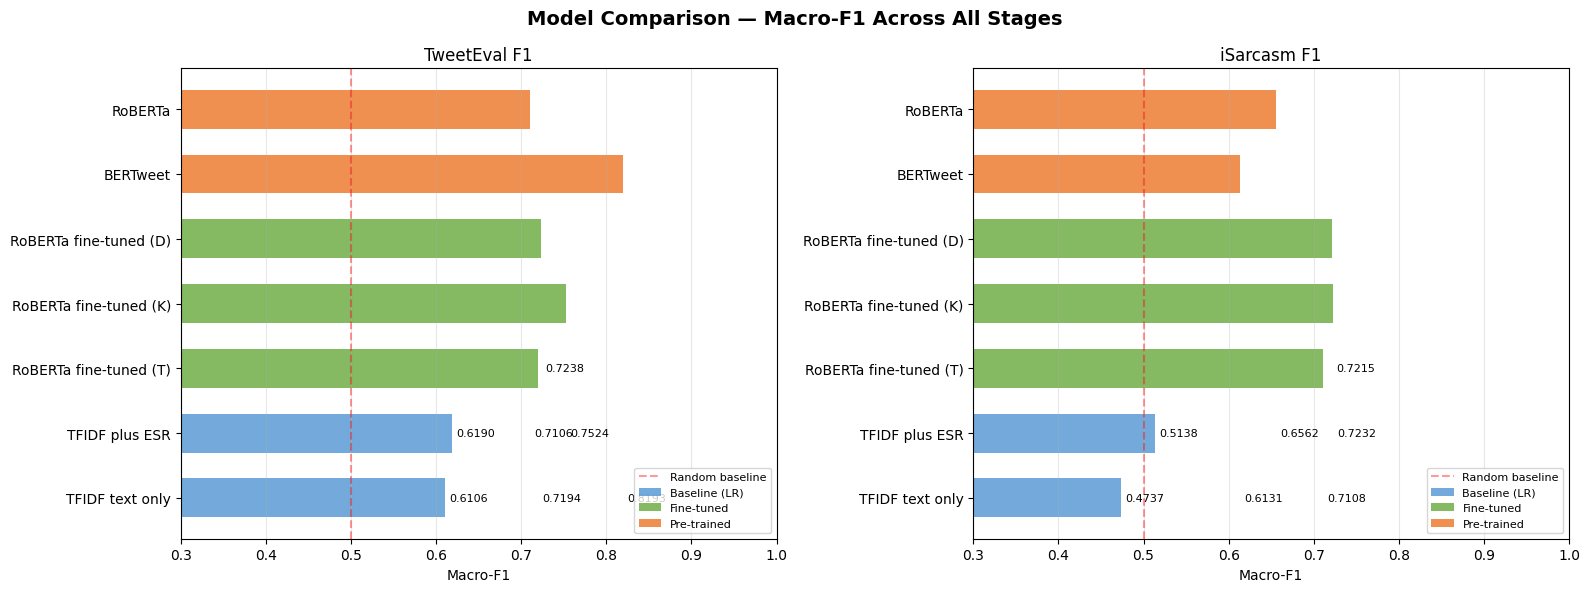

Saved to results/final_comparison.png


In [38]:
# Final Visual Comparison
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load results from CSVs
stage1 = pd.read_csv("results/stage1_tfidf_lr_results.csv")
stage2 = pd.read_csv("results/stage2_pretrained_summary.csv")
stage3_te = pd.read_csv("results/stage3_tweeteval_results.csv")
stage3_is = pd.read_csv("results/stage3_isarcasm_results.csv")

# Extract relevant rows
# TweetEval and iSarcasm only
s1_te = stage1[stage1["dataset"] == "tweeteval"][["variant", "macro_f1"]].copy()
s1_is = stage1[stage1["dataset"] == "isarcasm"][["variant", "macro_f1"]].copy()

# TweetEval and iSarcasm only
s2_te = stage2[stage2["dataset"] == "TweetEval"][["model", "macro_f1"]].copy()
s2_is = stage2[stage2["dataset"] == "iSarcasm"][["model", "macro_f1"]].copy()

# merge TweetEval and iSarcasm
stage3 = stage3_te.merge(stage3_is[["run_name", "iSarcasm_F1"]], on="run_name")

# unified comparison dataframe
rows = []

# Stage 1
for _, row in s1_te.iterrows():
    is_f1 = s1_is[s1_is["variant"] == row["variant"]]["macro_f1"].values
    rows.append({
        "Model" : row["variant"].replace("_", " "),
        "Stage" : "Baseline (LR)",
        "TweetEval F1": round(row["macro_f1"], 4),
        "iSarcasm F1" : round(is_f1[0], 4) if len(is_f1) > 0 else None,
    })

# Stage 2
for _, row in s2_te.iterrows():
    is_f1 = s2_is[s2_is["model"] == row["model"]]["macro_f1"].values
    rows.append({
        "Model" : row["model"],
        "Stage" : "Pre-trained",
        "TweetEval F1" : round(row["macro_f1"], 4),
        "iSarcasm F1" : round(is_f1[0], 4) if len(is_f1) > 0 else None,
    })

# Stage 3
for _, row in stage3.iterrows():
    rows.append({
        "Model" : f"RoBERTa fine-tuned ({row['emoji_mode']})",
        "Stage" : "Fine-tuned",
        "TweetEval F1": round(row["TweetEval_F1"], 4),
        "iSarcasm F1" : round(row["iSarcasm_F1"], 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("results/final_comparison.csv", index=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Comparison — Macro-F1 Across All Stages", fontsize=14, fontweight="bold")

colors = {
    "Baseline (LR)" : "#5B9BD5",
    "Pre-trained" : "#ED7D31",
    "Fine-tuned" : "#70AD47",
}

for ax, metric in zip(axes, ["TweetEval F1", "iSarcasm F1"]):
    for stage, group in comparison_df.groupby("Stage"):
        ax.barh(
            group["Model"],
            group[metric],
            color = colors[stage],
            label = stage,
            height = 0.6,
            alpha  = 0.85,
        )
        for _, r in group.iterrows():
            ax.text(
                r[metric] + 0.005,
                list(group["Model"]).index(r["Model"]) + list(comparison_df["Stage"].unique()).index(stage) * 0.001,
                f"{r[metric]:.4f}",
                va="center",
                fontsize=8,
            )

    ax.set_xlabel("Macro-F1")
    ax.set_title(metric)
    ax.set_xlim(0.3, 1.0)
    ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("results/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/final_comparison.png")